In [1]:
import os

os.chdir("../")

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.utils import resample
from statannotations.Annotator import Annotator

from src._config import IMG_DIR, MIN_BELIEF, MIN_SHOCKS, MAX_SHOCKS, N_OPPONENTS, N_TRIALS, PVALUE_MAP, QUALIT_PALETTE

FIG1_DIR = Path(IMG_DIR) / "fig1"
os.makedirs(FIG1_DIR, exist_ok=True)

## Load data

In [ ]:
pred = pd.read_csv("data/cohort_a/predictions.csv", header=None)
actual_vba = pd.read_csv("data/cohort_a/decisions.csv", header=None)
ids = pd.read_csv("data/cohort_a/subject_ids.csv")
bma = pd.read_csv("dev/Data/task3_cohortA_BMA.csv", index_col=0)

In [4]:
# Align indices (excluding outliers)
pred.index = ids["subject"]
actual_vba.index = ids["subject"]
common = pred.index.intersection(bma.index)
pred_114 = pred.loc[common].values
actual_114 = actual_vba.loc[common].values

# Sort by total shocks
sort_order = actual_114.sum(axis=1).argsort()
actual_sorted = actual_114[sort_order]
pred_sorted = pred_114[sort_order]

In [ ]:
script = pd.read_excel("data/shared/AggressionScript.xlsx", index_col="Session")
shocked = script.loc["Shocked"].values.astype(int)
shock_trials = np.where(shocked == 1)[0]

wins = script.loc["Win"].values.astype(int)

In [ ]:
aggro_performance = pd.read_excel(
    Path("data", "cohort_a", "aggroPerformance.xlsx"), index_col="Subject"
)

lat_performance = pd.read_excel(
    Path("data", "cohort_a", "latPerformance.xlsx"), index_col="Subject"
)

# Put latency performance into aggro performance
lat_columns = aggro_performance.columns.str.startswith("latency")
aggro_performance.loc[lat_performance.index, lat_columns] = lat_performance

aggro_performance.head()

## Heatmap: observed vs. predicted decisions

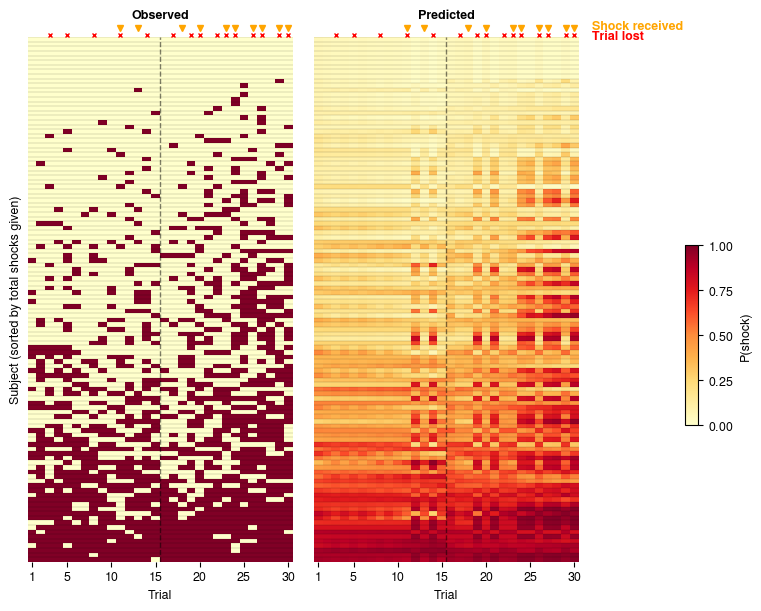

In [ ]:
# Plot
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(7, 6),
        gridspec_kw={"width_ratios": [1, 1, 0.05], "wspace": 0.08},
        layout="constrained",
    )

    cmap = "YlOrRd"

    sns.heatmap(
        actual_sorted,
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar=False,
        ax=axes[0],
    )
    axes[0].set_title("Observed", y=1.02, fontweight="bold")
    axes[0].set_ylabel("Subject (sorted by total shocks given)")
    sns.heatmap(
        pred_sorted,
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar=False,
        ax=axes[1],
    )
    axes[1].set_title("Predicted", y=1.02, fontweight="bold")
    ticks = [1, 5, 10, 15, 20, 25, 30]
    for ax in axes[:-1]:
        ax.set_xticks([t - 0.5 for t in ticks])
        ax.set_xticklabels(ticks)
        ax.set_xlabel("Trial")
        ax.axvline(x=15, color="black", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_yticks([])
        for i in range(len(actual_sorted)):
    ax.axhline(y=i, color="k", linewidth=0.1)
        for t in range(30):
    if shocked[t]:
        ax.plot(t + 0.5, -2.0, marker="v", color="orange", markersize=4, clip_on=False)
    if not wins[t]:
        ax.plot(t + 0.5, -0.5, marker="x", color="red",
            markersize=3, clip_on=False, markeredgewidth=1)
    axes[1].text(
        31.5, -0.25, "Trial lost", color="red", va="center", fontweight="bold"
    )
    axes[1].text(31.5, -2.25, "Shock received", color="orange", va="center", fontweight="bold")

    fig.colorbar(axes[1].collections[0], cax=axes[2], label="P(shock)")
    axes[2].set_yticks([0, 0.25, 0.5, 0.75, 1])
    axes[2].set_position(
        [axes[2].get_position().x0, 0.3, axes[2].get_position().width, 0.3]
    )
    plt.savefig(FIG1_DIR / "heatmaps.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG1_DIR / "heatmaps.pdf", bbox_inches="tight")
    plt.show()

## Shocks per opponent

In [11]:
shock_cols = []
lat_cols = []
chose_cols = []

for c in aggro_performance.columns:
    if c.startswith("shock"):
        shock_cols.append(c)
    elif c.startswith("latency"):
        lat_cols.append(c)
    elif c.startswith("chose"):
        chose_cols.append(c)

records = []
for i, (sc, lc, cc) in enumerate(zip(shock_cols, lat_cols, chose_cols)):
    trial = i + 1
    records.append(
        pd.DataFrame(
            {
                "subject": aggro_performance.index,
                "trial": trial,
                "opponent": (trial - 1) // N_TRIALS + 1,
                "shock": aggro_performance[sc].values,
                "latency": aggro_performance[lc].values,
                "chose": aggro_performance[cc].values,
            }
        )
    )

data = pd.concat(records, ignore_index=True)
data.head()

,subject,trial,opponent,shock,latency,chose
0,P035,1,1,0,1.740,1
1,P036,1,1,1,1.075,1
2,P039,1,1,0,1.538,1
3,P041,1,1,0,1.440,1
4,P042,1,1,0,NaN,0


In [74]:
# Check that we have the expected number of trials per opponent

print(data.groupby('opponent')['trial'].agg(['min', 'max', 'count']))

          min  max  count
opponent                 
1           1   15   1890
2          16   30   1890


In [75]:
# Shock x Chose crosstab
# chose=0 & shock=1 should be empty (no shock given if chose=0)

print(pd.crosstab(data['shock'], data['chose'], margins=True))
print(pd.crosstab(data["shock"], data["chose"], margins=True, normalize=True))

chose    0     1   All
shock                 
0      214  2324  2538
1        0  1242  1242
All    214  3566  3780
chose         0         1       All
shock                              
0      0.056614  0.614815  0.671429
1      0.000000  0.328571  0.328571
All    0.056614  0.943386  1.000000


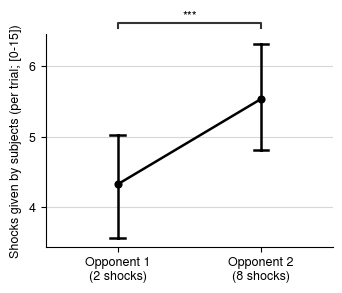

In [80]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    plot_data = data.groupby(["subject", "opponent"], as_index=False).shock.sum()
    plot_dict = {
        "data": plot_data,
        "x": "opponent",
        "y": "shock",
    }

    fig, ax = plt.subplots(figsize=(3.5, 3))
    sns.pointplot(
        **plot_dict,
        color="k",
        capsize=0.1,
        ax=ax
    )
    # handles, labels = ax.get_legend_handles_labels()
    ax.set_xticks(range(N_OPPONENTS))
    # shocks_from_opp = [shocked[:N_TRIALS].sum(), shocked[N_TRIALS:2*N_TRIALS].sum()]
    ax.set_xticklabels([f"Opponent {i + 1}\n({shocked[i * N_TRIALS:(i + 1) * N_TRIALS].sum()} shocks)" for i in range(N_OPPONENTS)])
    ax.set_ylabel("Shocks given by subjects (per trial; [0-15])")
    ax.set_xlabel("")
    ax.grid(alpha=0.5, axis="y", zorder=0)

    annotator = Annotator(
        ax, pairs=[(1, 2)],
        **plot_dict,
        verbose=False
    )
    annotator.configure(
        test="t-test_paired",
        # text_format="star",
        loc="outside",
        pvalue_format={"pvalue_thresholds": PVALUE_MAP},
        verbose=False,
    )
    annotator.apply_and_annotate()

    # Set ticks to be integers
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.savefig(FIG1_DIR / "shocks_given.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "shocks_given.png", dpi=300, bbox_inches="tight")
    plt.show()

## Trial duration by decision

In [ ]:
trials = pd.read_csv("data/shared/trial_events.csv")
trials_clean = trials[trials["choice"].notna() & trials["duration"].between(0, 30)]

trials_a = trials_clean[trials_clean["cohort"] == "A"]
trials_a["decision"] = trials_a["choice"].map(
    {"ring": "Loop enlarged", "shock": "Shock given"}
)

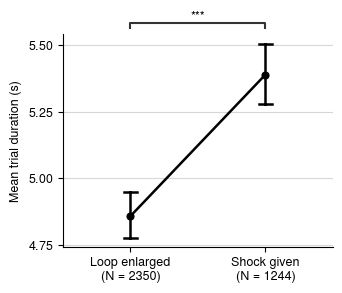

In [22]:
# Cohort A only
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    plot_dict = {
        "data": trials_a,
        "x": "decision",
        "y": "duration",
    }
    sns.pointplot(**plot_dict, color="k", capsize=0.1, ax=ax)

    annotator = Annotator(
        ax, pairs=[("Loop enlarged", "Shock given")],
        **plot_dict,
        verbose=False
    )
    ax.set_ylabel("Mean trial duration (s)")
    ax.set_xlabel("")
    ax.grid(alpha=0.5, axis="y", zorder=0)
    annotator.configure(
        test="t-test_ind",
        # text_format="star",
        loc="outside",
        pvalue_format={"pvalue_thresholds": PVALUE_MAP},
        verbose=False,
    )
    annotator.apply_and_annotate()

    counts = trials_a.groupby("decision").size()
    labels = [f"{d}\n(N = {counts[d]})" for d in ["Loop enlarged", "Shock given"]]
    ax.set_xticks(range(2))
    ax.set_xticklabels(labels)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.25))  # every 0.25s
    plt.savefig(FIG1_DIR / "trial_duration.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "trial_duration.png", dpi=300, bbox_inches="tight")
    plt.show()

## AUC across participants

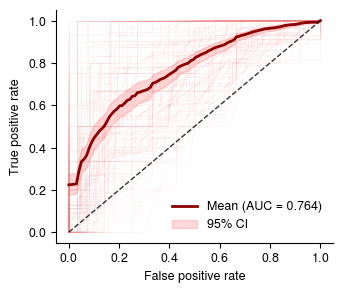

In [26]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))

    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    # Individual ROCs
    for i in range(len(pred_114)):
        y_true = actual_114[i]
        y_pred = pred_114[i]
        if len(np.unique(y_true)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        aucs.append(roc_auc_score(y_true, y_pred))
        ax.plot(fpr, tpr, color="lightcoral", alpha=0.1, linewidth=0.5)
        # Interpolate to common FPR grid for averaging
        tprs.append(np.interp(mean_fpr, fpr, tpr))

    # Mean ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = roc_auc_score(actual_114.flatten(), pred_114.flatten())  # or use per-subject mean
    ax.plot(mean_fpr, mean_tpr, color="darkred", linewidth=2, label=f"Mean (AUC = {np.mean(aucs):.3f})")

    # 0.5 line
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.8)

    # Bootstrap confidence intervals for mean AUC
    n_bootstrap = 1000
    tprs_array = np.array(tprs)  # (n_subjects, 100)

    boot_means = []
    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(tprs_array)), replace=True)
        boot_means.append(tprs_array[idx].mean(axis=0))

    boot_means = np.array(boot_means)
    tpr_lower = np.percentile(boot_means, 2.5, axis=0)
    tpr_upper = np.percentile(boot_means, 97.5, axis=0)

    ax.fill_between(
        mean_fpr, tpr_lower, tpr_upper, color="red", alpha=0.15, label="95% CI"
    )

    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend()
    plt.show()

## Calibration plot

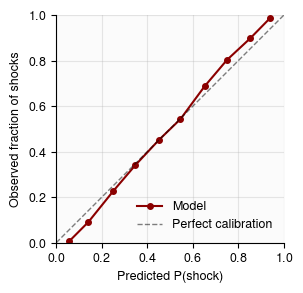

In [ ]:
y_true = actual_114.flatten()
y_pred = pred_114.flatten()

# Remove NaN if any
mask = ~np.isnan(y_pred) & ~np.isnan(y_true)

fraction_pos, mean_predicted = calibration_curve(y_true[mask], y_pred[mask], n_bins=10)

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    ax.plot(mean_predicted, fraction_pos, "o-", color="darkred", markersize=4, linewidth=1.5, label="Model")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfect calibration")
    ax.fill_between(
        [0, 1], [0, 0], [1, 1],
        where=[True, True],
        alpha=0.03, color="gray",
    )
    ax.set_xlabel("Predicted P(shock)")
    ax.set_ylabel("Observed fraction of shocks")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    plt.savefig(FIG1_DIR / "calibration.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "calibration.png", dpi=300, bbox_inches="tight")
    plt.show()

## Coefficient distributions

In [ ]:
coefs = pd.read_csv("data/cohort_a/coefficients.csv", index_col=0)

# Filter to 114 subjects
coefs_114 = coefs.loc[common]

coef_labels = {
    "Kp": r"$K_p$ (baseline)",
    "Kr1": r"$K_{r_1}$ (immediate reaction)",
    "Krc": r"$K_{r_c}$ (cumulative reaction)",
    "Kwc": r"$K_{w_c}$ (win-loss response)",
}

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(1, 4, figsize=(10, 2.5), sharey=True)

    for ax, (col, label) in zip(axes, coef_labels.items()):
        sns.histplot(coefs_114[col], kde=True, color="k", ax=ax, bins=15, edgecolor="white", linewidth=0.5)
        ax.set_xlabel(label)
        ax.set_ylabel("")
        ax.grid(alpha=0.3, axis="y")

    axes[0].set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG1_DIR / "coef_distributions.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "coef_distributions.png", dpi=300, bbox_inches="tight")
    plt.show()

# Print summary stats
print(coefs_114.describe().round(3))

## Shock vs. belief bivariate distribution (S5 -- exclusion criteria)

In [ ]:
# Load belief data
opponent_beliefs = pd.read_excel(Path("data", "cohort_a", "beliefs.xlsx"), index_col="ID")
if sorted(opponent_beliefs.columns) != ["opponent1", "opponent2"]:
    opponent_beliefs.rename(columns={k: k[4:] + k[0] for k in opponent_beliefs.columns}, inplace=True)
opponent_beliefs.drop("opponent3", axis=1, errors="ignore", inplace=True)

# Total shocks per subject (from aggro_performance directly, not melted data)
shock_cols_only = [c for c in aggro_performance.columns if c.startswith("shock")]
total_shocks = aggro_performance[shock_cols_only].sum(axis=1)

# Mean belief per subject
mean_belief = opponent_beliefs.mean(axis=1)

# Align indices
common_subj = total_shocks.index.intersection(mean_belief.dropna().index)
total_shocks = total_shocks.loc[common_subj]
mean_belief = mean_belief.loc[common_subj]

# Identify outliers: low belief AND extreme shocks
outliers = ((total_shocks < MIN_SHOCKS) | (total_shocks > MAX_SHOCKS)) & (mean_belief < MIN_BELIEF)

with plt.style.context(".matplotlib/paper.mplstyle"):
    g = sns.JointGrid(x=total_shocks, y=mean_belief, height=4)

    # Center: KDE + scatter
    sns.kdeplot(
        x=total_shocks, y=mean_belief,
        cut=1, cmap=sns.color_palette("Blues", as_cmap=True),
        fill=True, alpha=0.9, ax=g.ax_joint
    )
    g.ax_joint.scatter(total_shocks[~outliers], mean_belief[~outliers],
                       color="k", s=10, alpha=0.5, zorder=3)

    # Excluded subjects with jitter (clamped to >= 0)
    np.random.seed(42)
    jitter_y = np.abs(np.random.normal(0, 0.2, size=outliers.sum()))
    g.ax_joint.scatter(
        total_shocks[outliers],
        mean_belief[outliers] + jitter_y,
        color="darkred", edgecolor="k", s=30, alpha=0.8, zorder=5,
        label=f"Excluded (N={outliers.sum()})",
    )

    # Threshold lines (clipped to data range)
    g.ax_joint.plot([MIN_SHOCKS, MIN_SHOCKS], [0, MIN_BELIEF], linestyle="--", color="k", alpha=0.5, linewidth=0.8)
    g.ax_joint.plot([MAX_SHOCKS, MAX_SHOCKS], [0, MIN_BELIEF], linestyle="--", color="k", alpha=0.5, linewidth=0.8)
    g.ax_joint.plot([0, MIN_SHOCKS], [MIN_BELIEF, MIN_BELIEF], linestyle="--", color="k", alpha=0.5, linewidth=0.8)
    g.ax_joint.plot([MAX_SHOCKS, 30], [MIN_BELIEF, MIN_BELIEF], linestyle="--", color="k", alpha=0.5, linewidth=0.8)

    # Marginals: histograms
    sns.histplot(x=total_shocks, ax=g.ax_marg_x, color="gray", bins=15, edgecolor="white")
    sns.histplot(y=mean_belief, ax=g.ax_marg_y, color="gray", bins=10, edgecolor="white")

    g.ax_joint.set_xlabel("Total shocks given [0-30]")
    g.ax_joint.set_ylabel("Mean belief [0-10]")
    g.ax_joint.legend(fontsize=7, loc="upper right")

    plt.savefig(FIG1_DIR / "shock_vs_belief.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "shock_vs_belief.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"Excluded: {outliers.sum()} / {len(outliers)} participants")
print(f"Excluded subjects: {sorted(outliers[outliers].index.tolist())}")

## CONSORT flow diagram --> TODO

## Correlation matrix of model parameters (S3 -- identifiability)

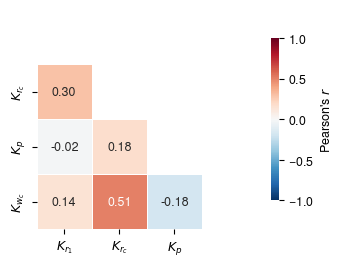

Correlation matrix (mean across 126 simulations):
[[ 1.     0.295 -0.022  0.143]
 [ 0.295  1.     0.178  0.508]
 [-0.022  0.178  1.    -0.184]
 [ 0.143  0.508 -0.184  1.   ]]


In [87]:
from scipy.io import loadmat

# Load posterior correlation matrix from simulation-recovery
corr_preds = loadmat("dev/Data/corr_preds.mat")["corr_preds"]

# Average across simulations
corr_mean = corr_preds.mean(axis=0)
mask = np.triu(np.ones(corr_mean.shape), k=0).astype(bool)
labels = [r"$K_{r_1}$", r"$K_{r_c}$", r"$K_p$", r"$K_{w_c}$"]

# Annotation: mean values as text
annot = np.array([[f"{corr_mean[i, j]:.2f}" for j in range(4)] for i in range(4)])

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    sns.heatmap(
        corr_mean,
        mask=mask,
        annot=annot,
        fmt="",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Pearson's $r$", "shrink": 0.6},
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    cbar = ax.collections[0].colorbar
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks(ax.get_yticks()[1:])
    ax.set_xticks(ax.get_xticks()[:-1])
    # ax.set_title("Model parameter correlations\n(simulation-recovery)", fontweight="bold")

    plt.savefig(FIG1_DIR / "corr_matrix.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "corr_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"Correlation matrix (mean across {corr_preds.shape[0]} simulations):")
print(np.round(corr_mean, 3))